# Root locus

In [1]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import sympy as sp

## Define the transfer function $G(s)$

In [2]:
# Open-loop transfer function G(s)
num = [1, 6, 12]
den = [1, 2, -4, -8]
G = ct.tf(num, den)

# Display the transfer function
s = sp.Symbol('s')

num_poly = sum(coef * s**i for i, coef in enumerate(reversed(num)))
den_poly = sum(coef * s**i for i, coef in enumerate(reversed(den)))

latex_standard = sp.latex(num_poly / den_poly)

display(Markdown(f"$$G(s) = {latex_standard}$$"))

$$G(s) = \frac{s^{2} + 6 s + 12}{s^{3} + 2 s^{2} - 4 s - 8}$$

The factorized polynomial is:

In [3]:
def factorize_polynomial(poly, symbol):
    p = sp.Poly(poly, symbol)
    lc = p.LC()           # extract the leading coefficient
    roots_dict = sp.roots(p)
    if not roots_dict:
        return sp.latex(poly)
    # reconstruct the factorized form based on their multiplicities
    factors = []
    for root, multiplicity in roots_dict.items():
        for _ in range(multiplicity):
            factors.append(symbol - root)
    factorized_form = sp.Mul(lc, *factors, evaluate=False)
    return sp.latex(factorized_form)


num_factorized = factorize_polynomial(num_poly, s)
den_factorized = factorize_polynomial(den_poly, s)

display(Markdown(f"$$G(s) = {latex_standard} = \\frac{{{num_factorized}}}{{{den_factorized}}}$$"))

$$G(s) = \frac{s^{2} + 6 s + 12}{s^{3} + 2 s^{2} - 4 s - 8} = \frac{1 \left(s + 3 + \sqrt{3} i\right) \left(s + 3 - \sqrt{3} i\right)}{1 \left(s - 2\right) \left(s + 2\right) \left(s + 2\right)}$$

## Draw the root locus

### Asymptotes centroid and angles
The centroid $\sigma_{\text{c}}$ is the intersection of the asymptotes with the real axis, and is calculated as:
$$\sigma_{\text{c}} = \frac{\sum \text{poles} - \sum \text{zeros}}{n - m}$$
where $n$ is the number of poles and $m$ is the number of zeros.

The angles of the asymptotes are given by:
$$\theta_{\text{k}} = \frac{(2k + 1)180^\circ}{n - m}$$
for $k = 0, 1, 2, \ldots, n - m - 1$.

In [4]:
poles = G.poles()
zeros = G.zeros()
n = len(poles)
m = len(zeros)


def format_latex_list(lst):
    if len(lst) == 0:
        return r"\emptyset"
    return ", ".join([str(np.round(p, 2)).strip('()') for p in lst])


output_md = "### Geometric Characteristics of the Root Locus"
output_md += "\n" + fr"- **Poles ($n={n}$):** ${format_latex_list(poles)}$"
output_md += "\n" + fr"- **Zeros ($m={m}$):** ${format_latex_list(zeros)}$"

if n > m:
    sigma_c = (np.sum(poles) - np.sum(zeros)) / (n - m)
    output_md += "\n" + fr"- **Asymptote Centroid:** $\sigma_c = {sigma_c.real:.4f}$"
    output_md += "\n" + fr"- **Asymptote Angles:**"

    for k in range(n - m):
        angle_rad = (2 * k + 1) * np.pi / (n - m)
        angle_deg = np.degrees(angle_rad)
        output_md += "\n" + fr"  * $\theta_{{{k}}} = {angle_deg:.1f}^\circ$ ($\dfrac{{{(2*k+1)}\pi}}{{{n-m}}}$ rad)"

display(Markdown(output_md))

### Geometric Characteristics of the Root Locus
- **Poles ($n=3$):** $2+0j, -2+0j, -2-0j$
- **Zeros ($m=2$):** $-3+1.73j, -3-1.73j$
- **Asymptote Centroid:** $\sigma_c = 4.0000$
- **Asymptote Angles:**
  * $\theta_{0} = 180.0^\circ$ ($\dfrac{1\pi}{1}$ rad)

### Breakaway and break-in points
The breakaway and break-in points on the root locus can be found by solving the equation:
$$D(s)N'(s) = D'(s)N(s)$$
where $N(s)$ is the numerator polynomial and $D(s)$ is the denominator polynomial of the open-loop transfer function $G(s)$.

The breakaway points occur where the root locus branches diverge from the real axis, while break-in points occur where they converge back to the real axis.

In alternative, you can use the following formula to determine the candidates breakaway/break-in (singular) points:
$$\sum_{i=1}^{n} \frac{1}{s - p_i} = \sum_{j=1}^{m} \frac{1}{s - z_j}$$

>Note that this formula will not give you the singular points corresponding to repeated poles or zeros of the open-loop (obvious singular points) and that the repeated poles and zeros in this formula need to be taken into account in the sum with their multiplicity.


A candidate point is valid only if the value of the gain $\hat k$ at those points is positive, which means:
$$\hat k = -\frac{D(s)}{N(s)} \ge 0$$


In [5]:
den_polynomial = np.poly1d(den)
num_polynomial = np.poly1d(num)
den_derivative = np.polyder(den_polynomial)
breakaway_candidates = np.roots(den_derivative)
results_md = "\n\n**Calculated Candidates:**\n"
for i, s_val in enumerate(breakaway_candidates):
    # k_hat = -1 / G(s) = -D(s) / N(s)
    k_hat = -np.polyval(den_polynomial, s_val) / np.polyval(num_polynomial, s_val)

    s_str = str(np.round(s_val, 4)).strip('()')
    k_str = str(np.round(k_hat, 4)).strip('()')

    # A point is valid on the root locus if k_hat is real and positive (> 0)
    is_valid = np.isreal(s_val) and np.isreal(k_hat) and k_hat.real >= 0
    status = "😊 **Valid**" if is_valid else "🙁 **Invalid**"

    results_md += f"* Candidate {i+1}: $s = {s_str}$ $\\rightarrow$ $\\hat{{k}} = {k_str}$ ({status})\n"

# Render everything together
display(Markdown(results_md))



**Calculated Candidates:**
* Candidate 1: $s = -2.0$ $\rightarrow$ $\hat{k} = -0.0$ (😊 **Valid**)
* Candidate 2: $s = 0.6667$ $\rightarrow$ $\hat{k} = 0.5766$ (😊 **Valid**)


### Intesection with the imaginary axis
To find the intersection of the root locus with the imaginary axis, we can use the Routh-Hurwitz criterion or directly substitute $s = j\omega$ into the characteristic equation and solve for $\omega$ and the corresponding gain $k$.

When substituting $s = j\omega$, we separate the real and imaginary parts of the characteristic equation and set them equal to zero to find the frequencies at which the root locus crosses the imaginary axis. Then, we can calculate the gain $k$ at those frequencies.

In [6]:
# Define symbolic variables
s = sp.Symbol('s')
K = sp.Symbol('K', real=True)
omega = sp.Symbol('omega', real=True)
char_eq = den_poly + K * num_poly
# Substitute s = j*omega (sp.I represents the imaginary unit 'j')
char_eq_jomega = char_eq.subs(s, sp.I * omega)

# Separate into Real and Imaginary equations
real_part = sp.re(char_eq_jomega)
imag_part = sp.im(char_eq_jomega)

# Solve the system of equations (Real = 0, Imag = 0) for K and omega
raw_solutions = sp.solve([real_part, imag_part], (K, omega))

output_md += "By substituting $s = j\\omega$ into the characteristic equation, we solve:\n"
output_md += f"$$D(j\\omega) + K N(j\\omega) = 0 \\rightarrow \\begin{{cases}} \\text{{Real: }} {sp.latex(real_part)} = 0 \\\\ \\text{{Imag: }} {sp.latex(imag_part)} = 0 \\end{{cases}}$$\n\n"

# Normalize solutions format to ensure easy iteration
if isinstance(raw_solutions, dict):
    solutions_list = [(raw_solutions.get(K), raw_solutions.get(omega))]
elif isinstance(raw_solutions, list):
    solutions_list = raw_solutions
else:
    solutions_list = [raw_solutions]

valid_crossings = 0
for sol in solutions_list:
    if isinstance(sol, tuple) and len(sol) == 2:
        K_val, omega_val = sol

        # Filter out purely complex/symbolic evaluation issues safely
        try:
            omega_float = float(omega_val)
            K_float = float(K_val)
        except (TypeError, ValueError):
            continue

        # We look for physical frequencies (omega >= 0)
        if omega_float >= 0:
            valid_crossings += 1
            output_md += f"* **Crossing {valid_crossings}:** At frequency $\\omega = {omega_float:.4f}$ rad/s, the root locus crosses the imaginary axis when the gain is **$K = {K_float:.4f}$**.\n"
            output_md += f"  * Intersection Coordinate: $s = {omega_float:.4f}j$\n"

if valid_crossings == 0:
    output_md += "* **Result:** The root locus branches never cross the imaginary axis for any real value of $K$.\n"

display(Markdown(output_md))

### Geometric Characteristics of the Root Locus
- **Poles ($n=3$):** $2+0j, -2+0j, -2-0j$
- **Zeros ($m=2$):** $-3+1.73j, -3-1.73j$
- **Asymptote Centroid:** $\sigma_c = 4.0000$
- **Asymptote Angles:**
  * $\theta_{0} = 180.0^\circ$ ($\dfrac{1\pi}{1}$ rad)By substituting $s = j\omega$ into the characteristic equation, we solve:
$$D(j\omega) + K N(j\omega) = 0 \rightarrow \begin{cases} \text{Real: } K \left(12 - \omega^{2}\right) - 2 \omega^{2} - 8 = 0 \\ \text{Imag: } 6 K \omega - \omega^{3} - 4 \omega = 0 \end{cases}$$

* **Crossing 1:** At frequency $\omega = 0.0000$ rad/s, the root locus crosses the imaginary axis when the gain is **$K = 0.6667$**.
  * Intersection Coordinate: $s = 0.0000j$


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


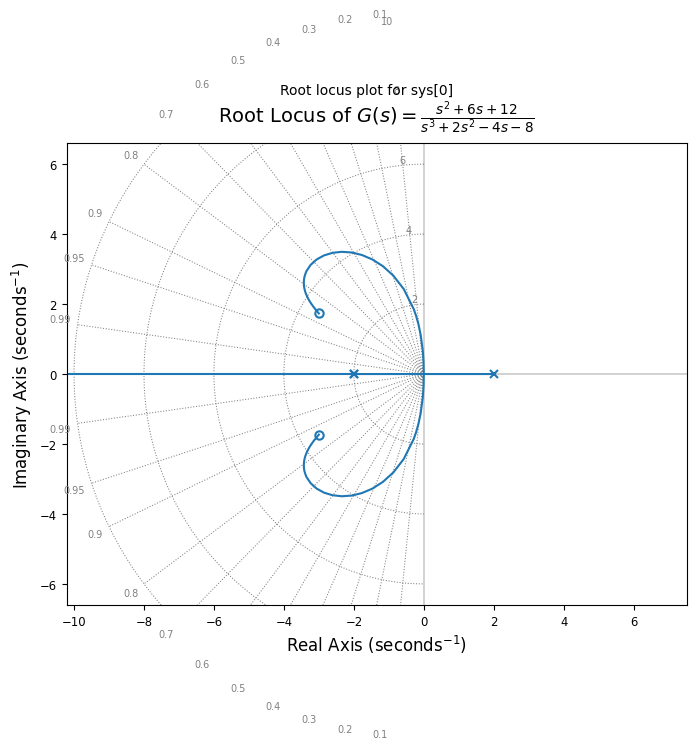

In [7]:
plt.figure(figsize=(8, 6))

ct.root_locus(G, grid=True)

plt.title(fr'Root Locus of $G(s) = {latex_standard}$', fontsize=14, pad=15)
plt.xlabel('Real Axis (seconds$^{-1}$)', fontsize=12)
plt.ylabel('Imaginary Axis (seconds$^{-1}$)', fontsize=12)


# Display the plot
plt.show()